# 🏡 California Housing Price Prediction
## End-to-End Machine Learning Project

**Objective:** Predict median housing prices in California districts using 1990 census data.  
**Problem Type:** Supervised Learning · Multiple Univariate Regression  
**Performance Metric:** Root Mean Square Error (RMSE)  

---
### Pipeline Overview
1. Look at the Big Picture
2. Get the Data
3. Discover and Visualize the Data
4. Prepare the Data for ML Algorithms
5. Select and Train Models
6. Fine-Tune the Best Model
7. Evaluate on Test Set & Present Results
8. Export Model for Deployment

---

## ⚙️ Step 0 — Install & Import Dependencies

In [ ]:
# Install any missing packages (Colab already has most)
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

In [ ]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import tarfile
import urllib.request
import warnings
warnings.filterwarnings('ignore')

# ── Numerical & DataFrame ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: data splitting ──────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    StratifiedShuffleSplit,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
)

# ── Scikit-learn: preprocessing ───────────────────────────────────────────────
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.impute import SimpleImputer

# ── Scikit-learn: pipeline & column transformer ───────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# ── Scikit-learn: models ──────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# ── Scikit-learn: metrics ─────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Persistence ───────────────────────────────────────────────────────────────
import joblib

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('muted')

print('✅ All imports successful.')

✅ All imports successful.


---
## 🔭 Step 1 — Look at the Big Picture

**Business context:**  
A real-estate investment company wants an automated system that takes census data for a California district and outputs a **median housing price prediction**.  
The downstream investment system will use the prediction to decide whether the district is worth investing in.

| Property | Value |
|---|---|
| Problem type | Supervised regression |
| Labels | `median_house_value` (continuous) |
| Features | 9 district-level attributes |
| Performance measure | RMSE (lower is better) |
| Batch vs Online | Batch (no streaming requirement) |

In [ ]:
# Helper: RMSE from cross-validation scores (sklearn returns neg MSE)
def display_cv_scores(scores, model_name='Model'):
    rmse_scores = np.sqrt(-scores)
    print(f"\n{'─'*50}")
    print(f" {model_name}  — 5-Fold CV Results")
    print(f"{'─'*50}")
    print(f"  RMSE scores : {np.round(rmse_scores, 0)}")
    print(f"  Mean RMSE   : {rmse_scores.mean():>10,.0f}")
    print(f"  Std  RMSE   : {rmse_scores.std():>10,.0f}")
    print(f"{'─'*50}")
    return rmse_scores

print('✅ Business objective defined. Performance measure: RMSE.')

✅ Business objective defined. Performance measure: RMSE.


---
## 📥 Step 2 — Get the Data

In [ ]:
# ── Download & extract ────────────────────────────────────────────────────────
DOWNLOAD_URL = (
    "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
    "datasets/housing/housing.tgz"
)
DATA_DIR  = "datasets/housing"
TGZ_PATH  = os.path.join(DATA_DIR, "housing.tgz")
CSV_PATH  = os.path.join(DATA_DIR, "housing.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    print("Downloading dataset …")
    urllib.request.urlretrieve(DOWNLOAD_URL, TGZ_PATH)
    with tarfile.open(TGZ_PATH) as tgz:
        tgz.extractall(path=DATA_DIR)
    print("✅ Download complete.")
else:
    print("✅ Dataset already present — skipping download.")

housing = pd.read_csv(CSV_PATH)
print(f"\nDataset shape : {housing.shape}  (rows × columns)")

✅ Download complete.

Dataset shape : (20640, 10)  (rows × columns)


In [ ]:
# ── Quick look ────────────────────────────────────────────────────────────────
print("=== First 5 rows ===")
display(housing.head())

print("\n=== Data types & non-null counts ===")
housing.info()

print("\n=== Descriptive statistics ===")
display(housing.describe().T.style.format('{:.2f}'))

=== First 5 rows ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



=== Data types & non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

=== Descriptive statistics ===


,count,mean,std,min,25%,50%,75%,max
longitude,20640.00,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.00,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.00,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.00,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20433.00,537.87,421.39,1.00,296.00,435.00,647.00,6445.00
population,20640.00,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.00,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.00,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.00,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00


In [ ]:
# ── Missing values ────────────────────────────────────────────────────────────
null_counts = housing.isnull().sum()
null_pct    = (null_counts / len(housing) * 100).round(2)
null_df     = pd.DataFrame({'missing_count': null_counts, 'missing_%': null_pct})
null_df     = null_df[null_df['missing_count'] > 0]

print("=== Columns with missing values ===")
if null_df.empty:
    print("  None found.")
else:
    display(null_df)

print(f"\nocean_proximity value counts:")
print(housing['ocean_proximity'].value_counts())

=== Columns with missing values ===


,missing_count,missing_%
total_bedrooms,207,1.0



ocean_proximity value counts:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [ ]:
# ── Stratified train/test split on income category ───────────────────────────
# Bin median_income into 5 categories (used only for stratification)
housing['income_cat'] = pd.cut(
    housing['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

split = StratifiedShuffleSplit(
    n_splits=1, test_size=0.2, random_state=RANDOM_STATE
)
for train_idx, test_idx in split.split(housing, housing['income_cat']):
    strat_train = housing.iloc[train_idx].copy()
    strat_test  = housing.iloc[test_idx].copy()

# Drop helper column
for df in (strat_train, strat_test, housing):
    df.drop(columns=['income_cat'], inplace=True)

print(f"Training set   : {len(strat_train):,} rows")
print(f"Test set       : {len(strat_test):,} rows")

# Verify stratification quality
def income_cat_proportions(data):
    return pd.cut(
        data['median_income'],
        bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
        labels=[1, 2, 3, 4, 5]
    ).value_counts() / len(data)

compare = pd.DataFrame({
    'Overall': income_cat_proportions(housing),
    'Train':   income_cat_proportions(strat_train),
    'Test':    income_cat_proportions(strat_test),
}).sort_index()
compare['Train error %'] = ((compare['Train'] - compare['Overall']) / compare['Overall'] * 100).round(2)
compare['Test error %']  = ((compare['Test']  - compare['Overall']) / compare['Overall'] * 100).round(2)
print("\n=== Stratification quality (income category proportions) ===")
display(compare)

Training set   : 16,512 rows
Test set       : 4,128 rows

=== Stratification quality (income category proportions) ===


,Overall,Train,Test,Train error %,Test error %
median_income,,,,,
1,0.039826,0.039789,0.039971,-0.09,0.36
2,0.318847,0.318859,0.318798,0.00,-0.02
3,0.350581,0.350594,0.350533,0.00,-0.01
4,0.176308,0.176296,0.176357,-0.01,0.03
5,0.114438,0.114462,0.114341,0.02,-0.08


---
## 🔍 Step 3 — Discover and Visualize the Data

> **Important:** All EDA is performed **only on the training set** to avoid data leakage.

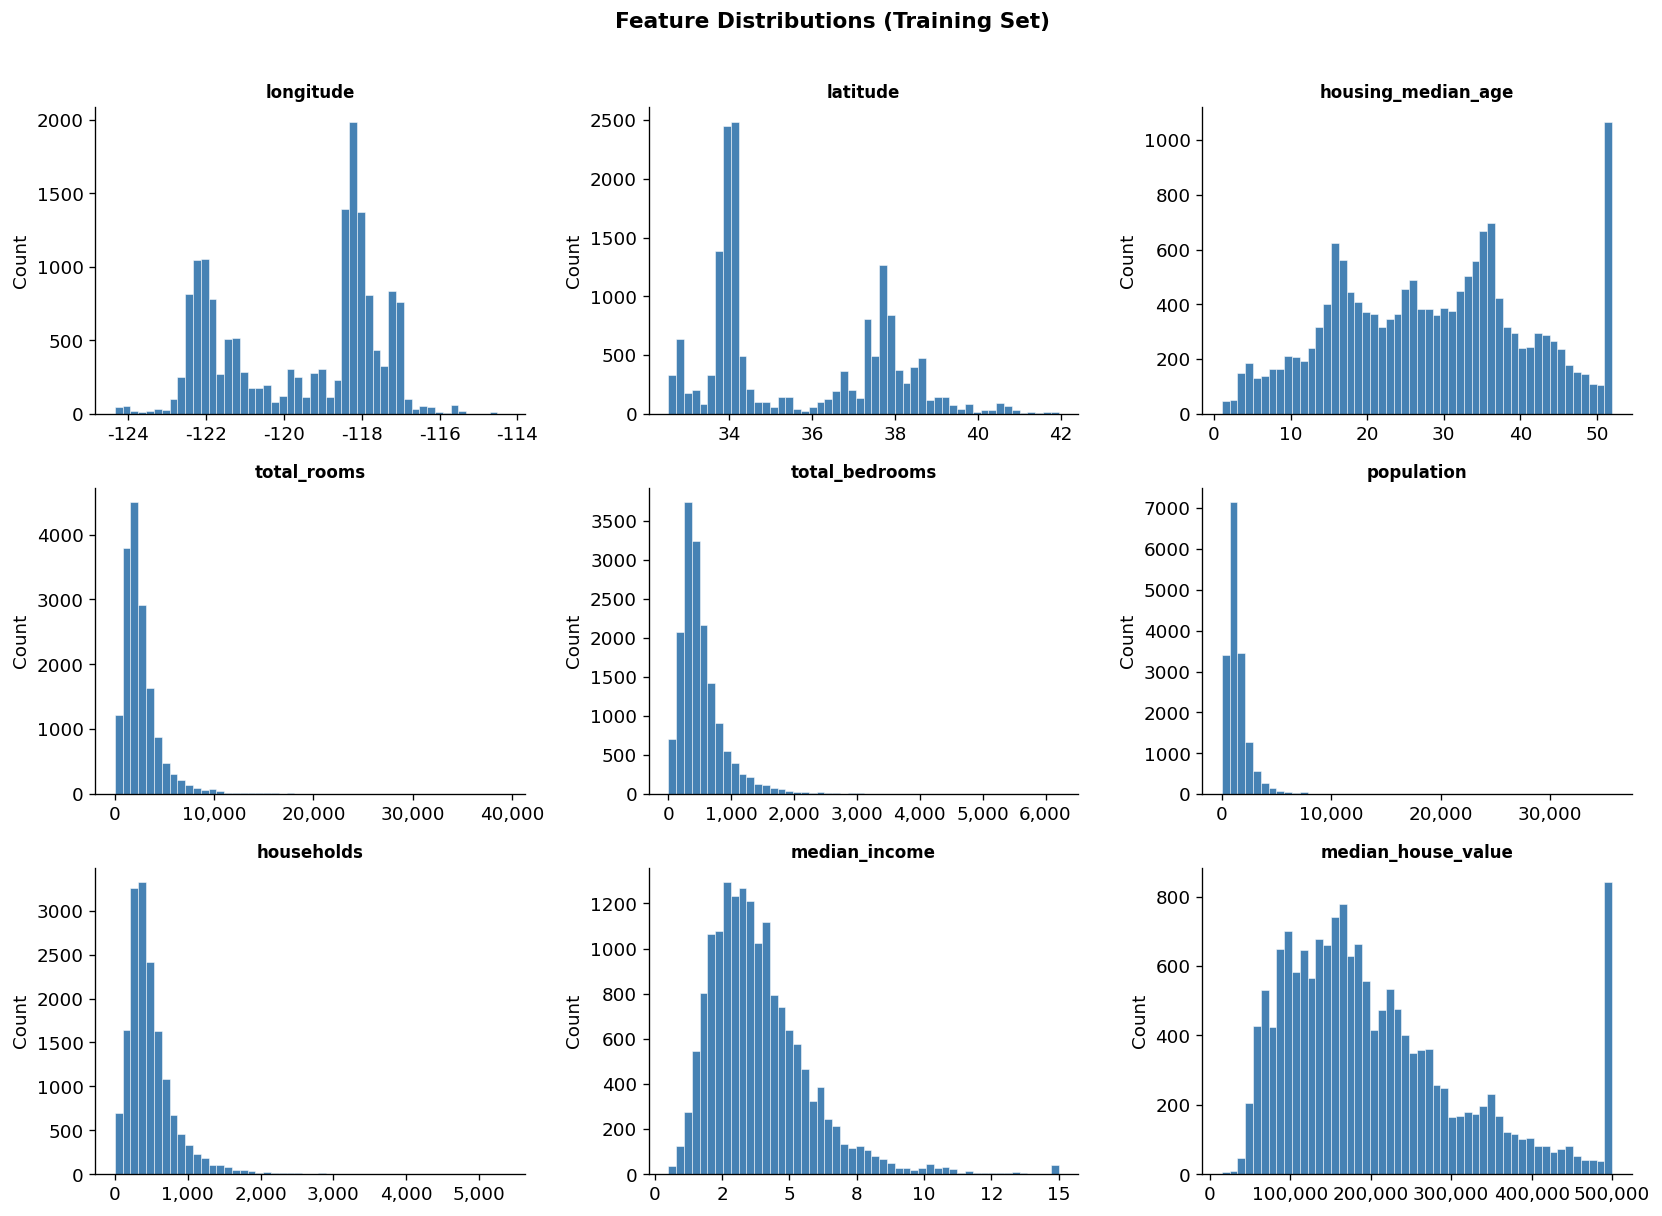


⚠️  Note: median_house_value is capped at $500,000 — a known dataset artifact.


In [ ]:
# ── Histograms of all numerical features ─────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
num_cols = strat_train.select_dtypes(include=[np.number]).columns.tolist()

for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(strat_train[col].dropna(), bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Hide any spare axes
for ax in axes.flatten()[len(num_cols):]:
    ax.set_visible(False)

plt.suptitle('Feature Distributions (Training Set)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_feature_distributions.png', bbox_inches='tight')
plt.show()
print("\n⚠️  Note: median_house_value is capped at $500,000 — a known dataset artifact.")

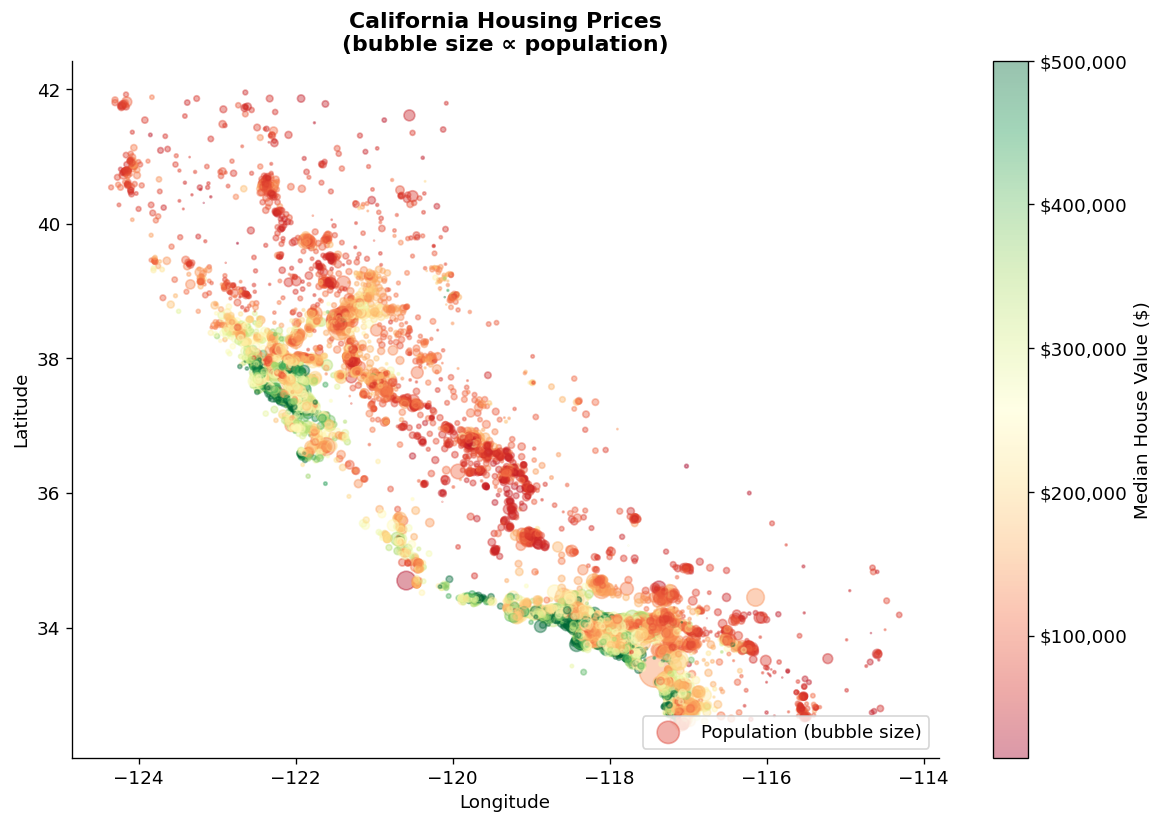

In [ ]:
# ── Geographic scatter plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    strat_train['longitude'],
    strat_train['latitude'],
    c=strat_train['median_house_value'],
    cmap='RdYlGn',
    alpha=0.4,
    s=strat_train['population'] / 100,
    label='Population (bubble size)',
)
cbar = plt.colorbar(scatter, ax=ax, label='Median House Value ($)')
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('California Housing Prices\n(bubble size ∝ population)', fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('02_geo_price_map.png', bbox_inches='tight')
plt.show()

=== Pearson correlation with median_house_value ===
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673


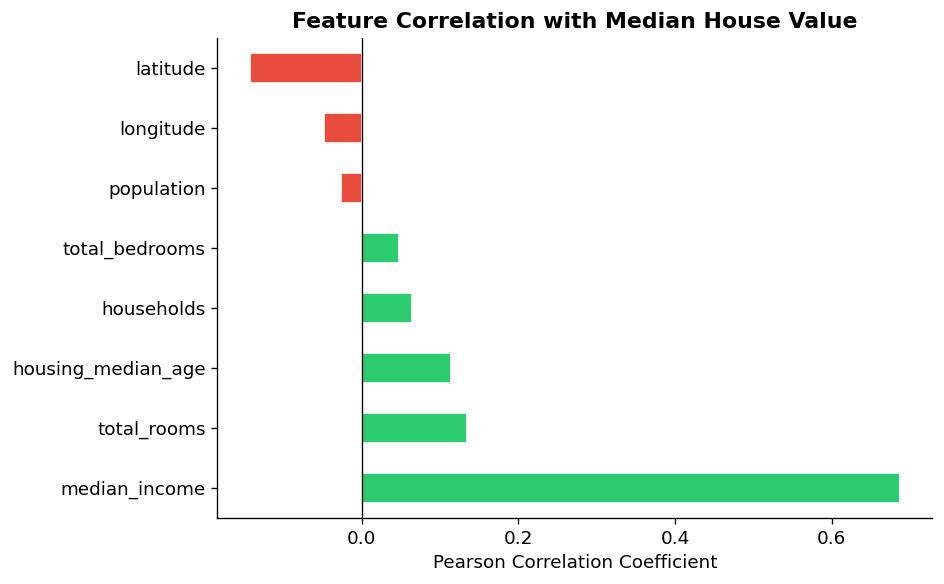

In [ ]:
# ── Pearson correlation with target ──────────────────────────────────────────
corr_matrix = strat_train.select_dtypes(include=[np.number]).corr()
target_corr = corr_matrix['median_house_value'].drop('median_house_value').sort_values(ascending=False)

print("=== Pearson correlation with median_house_value ===")
print(target_corr.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_title('Feature Correlation with Median House Value', fontweight='bold')
plt.tight_layout()
plt.savefig('03_correlations.png', bbox_inches='tight')
plt.show()

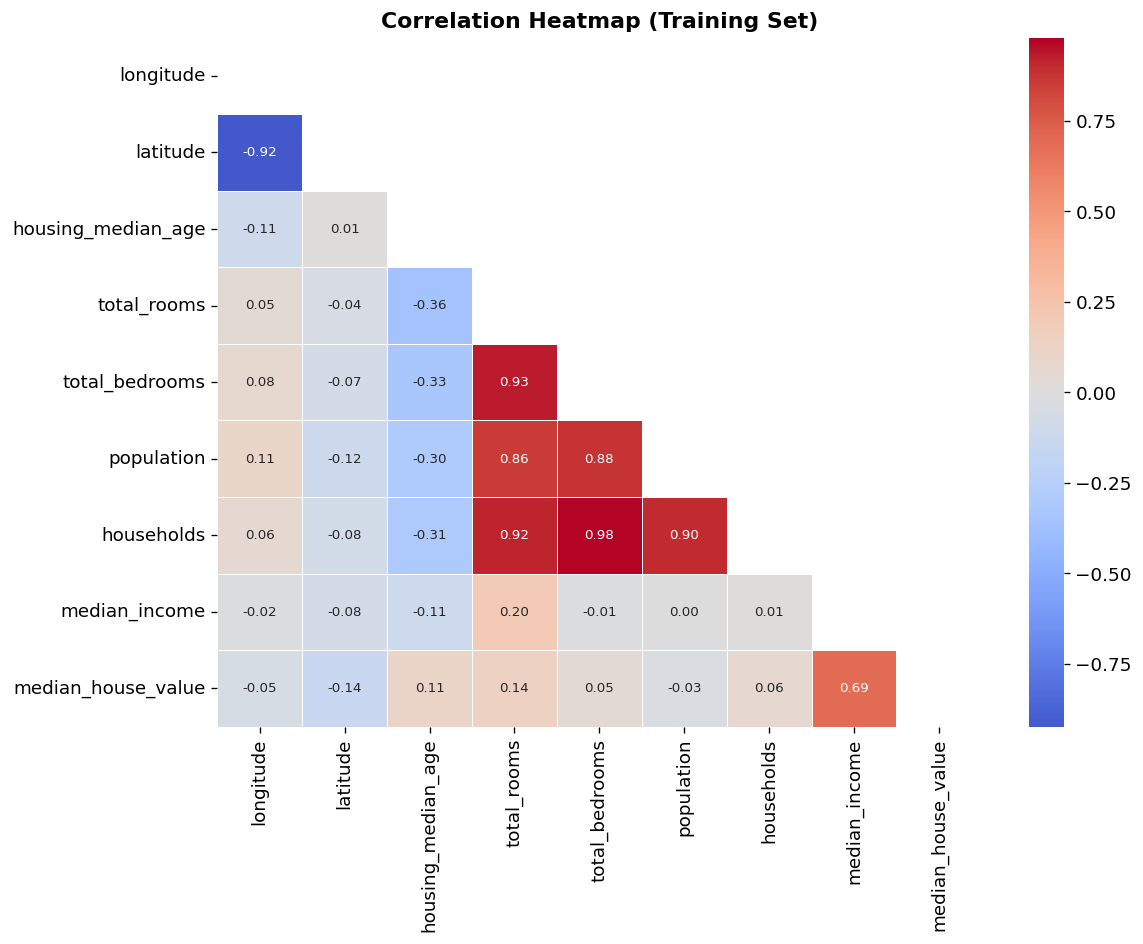

In [ ]:
# ── Full correlation heatmap ──────────────────────────────────────────────────
num_train = strat_train.select_dtypes(include=[np.number])
corr_full = num_train.corr()

mask = np.triu(np.ones_like(corr_full, dtype=bool))  # upper triangle
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_full, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Heatmap (Training Set)', fontweight='bold')
plt.tight_layout()
plt.savefig('04_heatmap.png', bbox_inches='tight')
plt.show()

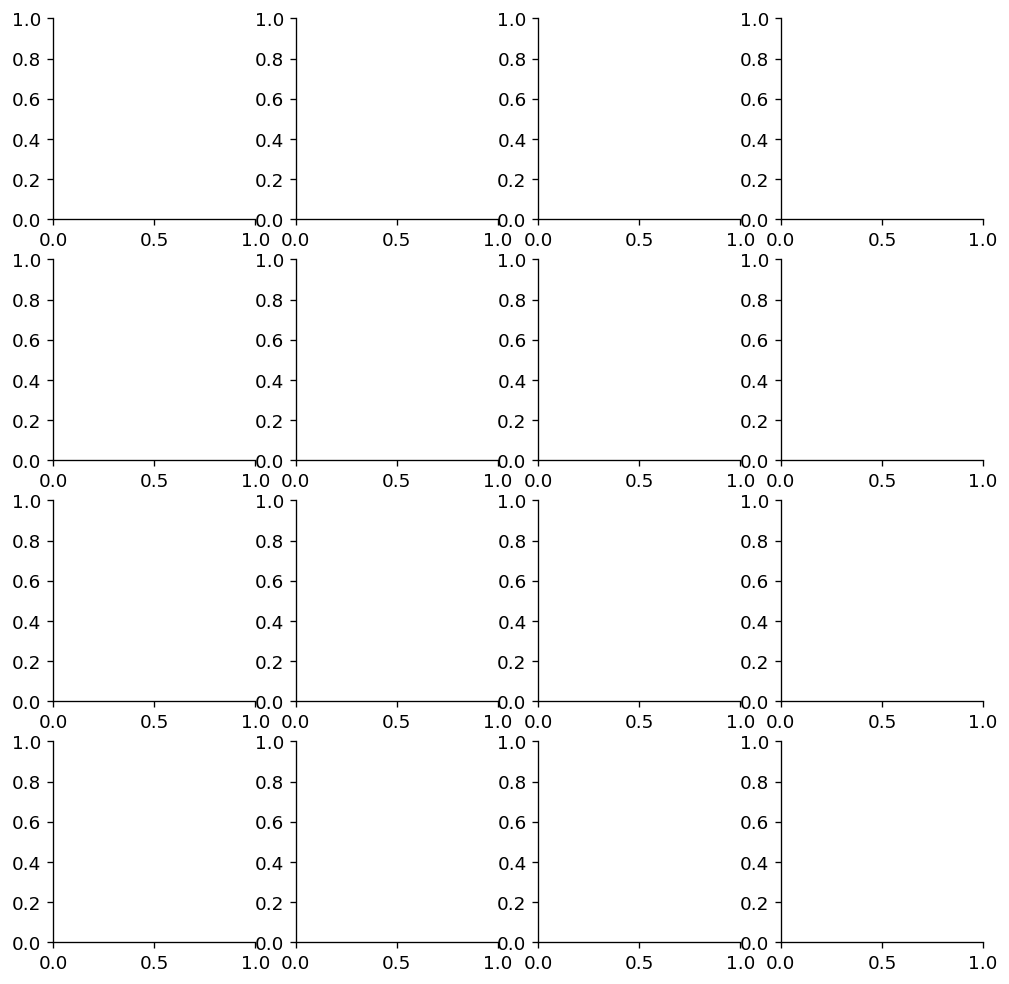

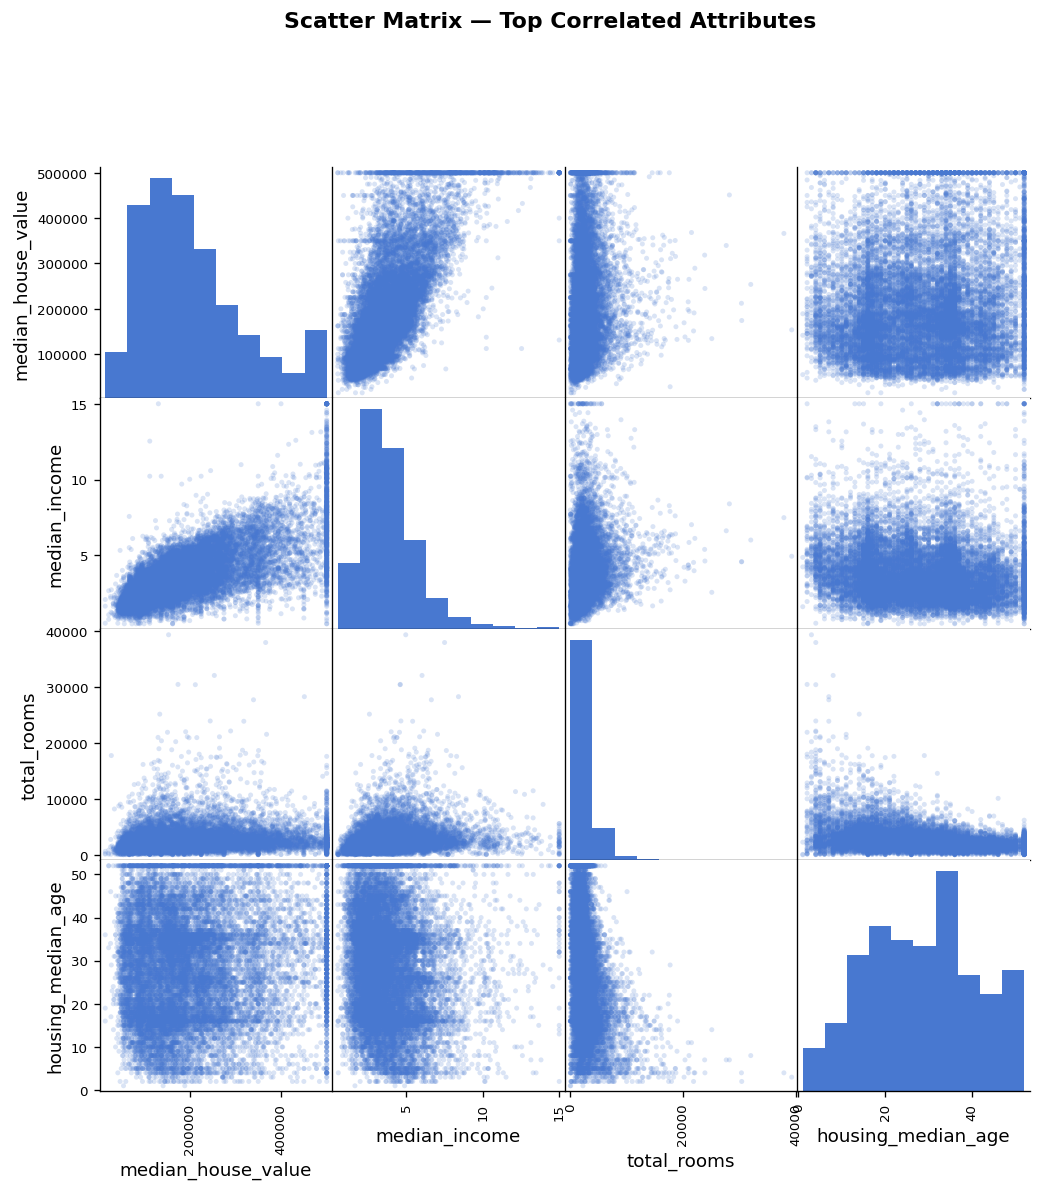

In [ ]:
# ── Scatter matrix for top correlators ───────────────────────────────────────
top_attrs = [
    'median_house_value', 'median_income',
    'total_rooms', 'housing_median_age',
]
from pandas.plotting import scatter_matrix
fig, axes = plt.subplots(len(top_attrs), len(top_attrs), figsize=(10, 10))
scatter_matrix(strat_train[top_attrs], alpha=0.2, figsize=(10, 10), diagonal='hist')
plt.suptitle('Scatter Matrix — Top Correlated Attributes', fontweight='bold', y=1.01)
plt.savefig('05_scatter_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Engineer and inspect derived features ────────────────────────────────────
# These combinations will be added formally in the pipeline (Step 4)
tmp = strat_train.copy()
tmp['rooms_per_household']   = tmp['total_rooms']    / tmp['households']
tmp['bedrooms_per_room']     = tmp['total_bedrooms'] / tmp['total_rooms']
tmp['population_per_hh']     = tmp['population']     / tmp['households']

derived_corr = tmp[[
    'rooms_per_household', 'bedrooms_per_room',
    'population_per_hh', 'median_house_value'
]].corr()['median_house_value'].drop('median_house_value').sort_values(ascending=False)

print("=== Correlation of derived features with target ===")
print(derived_corr.to_string())
print("\n✅  rooms_per_household shows strong positive correlation — will be added to pipeline.")
print("✅  bedrooms_per_room shows strong negative correlation — will be added to pipeline.")

del tmp

=== Correlation of derived features with target ===
rooms_per_household    0.146255
population_per_hh     -0.021991
bedrooms_per_room     -0.259952

✅  rooms_per_household shows strong positive correlation — will be added to pipeline.
✅  bedrooms_per_room shows strong negative correlation — will be added to pipeline.


---
## 🛠️ Step 4 — Prepare the Data for ML Algorithms

In [ ]:
# ── Separate features and target ──────────────────────────────────────────────
TARGET = 'median_house_value'

X_train = strat_train.drop(columns=[TARGET])
y_train = strat_train[TARGET].copy()

X_test  = strat_test.drop(columns=[TARGET])
y_test  = strat_test[TARGET].copy()

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")

X_train : (16512, 9)   y_train : (16512,)
X_test  : (4128, 9)    y_test  : (4128,)


In [ ]:
# ── Custom transformer: add engineered ratio features ─────────────────────────
class RatioFeaturesAdder(BaseEstimator, TransformerMixin):
    """
    Adds three ratio features that correlate more strongly with
    median_house_value than raw counts.

    New columns (appended after existing ones):
        rooms_per_household   = total_rooms    / households
        bedrooms_per_room     = total_bedrooms / total_rooms
        population_per_hh     = population     / households
    """

    # Column positions in the NUMERICAL feature matrix
    _ROOMS_IDX    = 3   # total_rooms
    _BEDROOMS_IDX = 4   # total_bedrooms
    _POPULATION_IDX = 5 # population
    _HOUSEHOLDS_IDX = 6 # households

    def fit(self, X, y=None):
        return self  # stateless transformer

    def transform(self, X):
        X = np.array(X, dtype=np.float64)
        rooms_per_hh   = X[:, self._ROOMS_IDX]    / X[:, self._HOUSEHOLDS_IDX]
        bedrooms_ratio = X[:, self._BEDROOMS_IDX] / X[:, self._ROOMS_IDX]
        pop_per_hh     = X[:, self._POPULATION_IDX] / X[:, self._HOUSEHOLDS_IDX]
        return np.c_[X, rooms_per_hh, bedrooms_ratio, pop_per_hh]

print('✅ RatioFeaturesAdder defined.')

✅ RatioFeaturesAdder defined.


In [ ]:
# ── Identify column types ─────────────────────────────────────────────────────
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numerical features ({len(num_features)}) : {num_features}")
print(f"Categorical features ({len(cat_features)}) : {cat_features}")

# ── Numerical pipeline ────────────────────────────────────────────────────────
num_pipeline = Pipeline([
    ('imputer',       SimpleImputer(strategy='median')),   # fills total_bedrooms NaNs
    ('ratio_adder',   RatioFeaturesAdder()),               # adds 3 engineered features
    ('std_scaler',    StandardScaler()),                   # zero-mean, unit-variance
])

# ── Categorical pipeline ──────────────────────────────────────────────────────
cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ── Full preprocessing ColumnTransformer ─────────────────────────────────────
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
])

# ── Fit on TRAINING data only, then transform both sets ──────────────────────
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared  = full_pipeline.transform(X_test)

# Derive feature names for interpretability
onehot_names   = full_pipeline.named_transformers_['cat']['onehot'].get_feature_names_out(cat_features).tolist()
ratio_names    = ['rooms_per_household', 'bedrooms_per_room', 'population_per_hh']
feature_names  = num_features + ratio_names + onehot_names

print(f"\n✅ Preprocessing complete.")
print(f"   X_train_prepared shape : {X_train_prepared.shape}")
print(f"   X_test_prepared  shape : {X_test_prepared.shape}")
print(f"   Total features         : {len(feature_names)}")
print(f"   Feature list           : {feature_names}")

Numerical features (8) : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features (1) : ['ocean_proximity']

✅ Preprocessing complete.
   X_train_prepared shape : (16512, 16)
   X_test_prepared  shape : (4128, 16)
   Total features         : 16
   Feature list           : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_hh', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


---
## 🤖 Step 5 — Select and Train Models

We evaluate four candidate models using **5-fold cross-validation** on the training set.

In [ ]:
# ── 5.1  Linear Regression (baseline) ────────────────────────────────────────
lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

lin_scores = cross_val_score(
    lin_reg, X_train_prepared, y_train,
    scoring='neg_mean_squared_error', cv=5
)
lin_rmse = display_cv_scores(lin_scores, 'Linear Regression')


──────────────────────────────────────────────────
 Linear Regression  — 5-Fold CV Results
──────────────────────────────────────────────────
  RMSE scores : [68077. 67881. 69713. 71267. 68390.]
  Mean RMSE   :     69,066
  Std  RMSE   :      1,273
──────────────────────────────────────────────────


In [ ]:
# ── 5.2  Decision Tree Regressor ──────────────────────────────────────────────
tree_reg = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_reg.fit(X_train_prepared, y_train)

tree_scores = cross_val_score(
    tree_reg, X_train_prepared, y_train,
    scoring='neg_mean_squared_error', cv=5
)
tree_rmse = display_cv_scores(tree_scores, 'Decision Tree')


──────────────────────────────────────────────────
 Decision Tree  — 5-Fold CV Results
──────────────────────────────────────────────────
  RMSE scores : [68962. 70999. 67538. 73579. 71144.]
  Mean RMSE   :     70,445
  Std  RMSE   :      2,063
──────────────────────────────────────────────────


In [ ]:
# ── 5.3  Random Forest Regressor ─────────────────────────────────────────────
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,        # use all CPU cores
)
rf_reg.fit(X_train_prepared, y_train)

rf_scores = cross_val_score(
    rf_reg, X_train_prepared, y_train,
    scoring='neg_mean_squared_error', cv=5
)
rf_rmse = display_cv_scores(rf_scores, 'Random Forest')


──────────────────────────────────────────────────
 Random Forest  — 5-Fold CV Results
──────────────────────────────────────────────────
  RMSE scores : [50219. 49534. 50073. 51777. 51705.]
  Mean RMSE   :     50,662
  Std  RMSE   :        911
──────────────────────────────────────────────────


In [ ]:
# ── 5.4  Gradient Boosting Regressor ─────────────────────────────────────────
gbr_reg = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=RANDOM_STATE,
)
gbr_reg.fit(X_train_prepared, y_train)

gbr_scores = cross_val_score(
    gbr_reg, X_train_prepared, y_train,
    scoring='neg_mean_squared_error', cv=5
)
gbr_rmse = display_cv_scores(gbr_scores, 'Gradient Boosting')


──────────────────────────────────────────────────
 Gradient Boosting  — 5-Fold CV Results
──────────────────────────────────────────────────
  RMSE scores : [48191. 48170. 47701. 50205. 49417.]
  Mean RMSE   :     48,737
  Std  RMSE   :        929
──────────────────────────────────────────────────


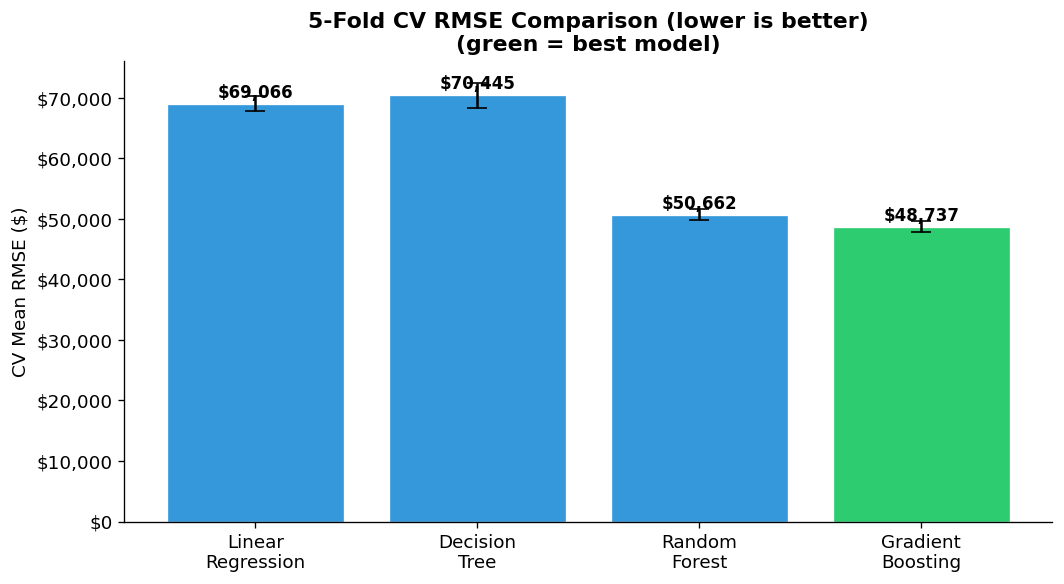


🏆 Best candidate: Gradient Boosting  (CV RMSE ≈ $48,737)


In [ ]:
# ── Model comparison chart ────────────────────────────────────────────────────
model_names  = ['Linear\nRegression', 'Decision\nTree', 'Random\nForest', 'Gradient\nBoosting']
mean_rmses   = [lin_rmse.mean(), tree_rmse.mean(), rf_rmse.mean(), gbr_rmse.mean()]
std_rmses    = [lin_rmse.std(),  tree_rmse.std(),  rf_rmse.std(),  gbr_rmse.std()]

best_idx = int(np.argmin(mean_rmses))
colors   = ['#3498db' if i != best_idx else '#2ecc71' for i in range(len(model_names))]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, mean_rmses, yerr=std_rmses, capsize=6,
              color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, mean_rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('CV Mean RMSE ($)')
ax.set_title('5-Fold CV RMSE Comparison (lower is better)\n(green = best model)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('06_model_comparison.png', bbox_inches='tight')
plt.show()

print(f"\n🏆 Best candidate: {model_names[best_idx].replace(chr(10),' ')}  (CV RMSE ≈ ${mean_rmses[best_idx]:,.0f})")

---
## 🎯 Step 6 — Fine-Tune the Best Model (Random Forest)

We use **RandomizedSearchCV** first for a broad search, then narrow down with **GridSearchCV**.

In [ ]:
# ── 6.1  Randomized Search ────────────────────────────────────────────────────
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# --- BEGIN: Dependencies for X_train_prepared and y_train (added for self-containment) ---
# This section duplicates code from previous cells (Get the Data, Prepare the Data for ML Algorithms)
# to ensure X_train_prepared and y_train are defined when this cell is executed independently.
# In a typical sequential notebook run, these variables would already be in scope.

# Standard library imports (assuming basic pandas/numpy are available or imported globally)
import os
import tarfile
import urllib.request
import pandas as pd
import numpy as np

# Scikit-learn imports for data splitting, preprocessing, and pipelines
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Define RANDOM_STATE for reproducibility (if not globally available)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- 2. Get the Data (simplified, focusing on 'housing' dataframe) ---
DOWNLOAD_URL = (
    "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
    "datasets/housing/housing.tgz"
)
DATA_DIR  = "datasets/housing"
TGZ_PATH  = os.path.join(DATA_DIR, "housing.tgz")
CSV_PATH  = os.path.join(DATA_DIR, "housing.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    print("Downloading dataset within random-search cell...")
    urllib.request.urlretrieve(DOWNLOAD_URL, TGZ_PATH)
    with tarfile.open(TGZ_PATH) as tgz:
        tgz.extractall(path=DATA_DIR)
else:
    print("Dataset already present, skipping download within random-search cell.")
housing = pd.read_csv(CSV_PATH)

# --- Stratified train/test split (from train-test-split cell) ---
housing['income_cat'] = pd.cut(
    housing['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
for train_idx, test_idx in split.split(housing, housing['income_cat']):
    strat_train = housing.iloc[train_idx].copy()
    strat_test  = housing.iloc[test_idx].copy()
for df in (strat_train, strat_test, housing):
    df.drop(columns=['income_cat'], inplace=True, errors='ignore') # errors='ignore' for safety

# --- Separate features and target (from separate-labels cell) ---
TARGET = 'median_house_value'
X_train = strat_train.drop(columns=[TARGET])
y_train = strat_train[TARGET].copy()

# --- Custom transformer (from custom-transformer cell) ---
class RatioFeaturesAdder(BaseEstimator, TransformerMixin):
    _ROOMS_IDX    = 3   # total_rooms
    _BEDROOMS_IDX = 4   # total_bedrooms
    _POPULATION_IDX = 5 # population
    _HOUSEHOLDS_IDX = 6 # households

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X, dtype=np.float64)
        rooms_per_hh   = X[:, self._ROOMS_IDX]    / X[:, self._HOUSEHOLDS_IDX]
        bedrooms_ratio = X[:, self._BEDROOMS_IDX] / X[:, self._ROOMS_IDX]
        pop_per_hh     = X[:, self._POPULATION_IDX] / X[:, self._HOUSEHOLDS_IDX]
        return np.c_[X, rooms_per_hh, bedrooms_ratio, pop_per_hh]

# --- Build preprocessing pipeline (from build-pipeline cell) ---
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

num_pipeline = Pipeline([
    ('imputer',       SimpleImputer(strategy='median')),
    ('ratio_adder',   RatioFeaturesAdder()),
    ('std_scaler',    StandardScaler()),
])
cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
])

X_train_prepared = full_pipeline.fit_transform(X_train)
# The following line was removed as X_test is not defined in this self-contained block
# and X_test_prepared is not needed for rnd_search.fit
# X_test_prepared  = full_pipeline.transform(X_test)
# --- END: Dependencies for X_train_prepared and y_train ---

param_distributions = {
    'n_estimators'     : randint(50, 500),
    'max_features'     : ['sqrt', 'log2', None],
    'max_depth'        : [None, 10, 20, 30, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'bootstrap'        : [True, False],
}

rnd_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    refit=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

print("Running RandomizedSearchCV (50 iterations × 5 folds = 250 fits) …")
rnd_search.fit(X_train_prepared, y_train)

print(f"\n✅  Best params  : {rnd_search.best_params_}")
print(f"   Best CV RMSE : ${np.sqrt(-rnd_search.best_score_):,.0f}")

Dataset already present, skipping download within random-search cell.
Running RandomizedSearchCV (50 iterations × 5 folds = 250 fits) …
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



✅  Best params  : {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 353}
   Best CV RMSE : $48,721


In [ ]:
# ── 6.2  Grid Search (narrow around RandomizedSearch best params) ─────────────
from sklearn.model_selection import GridSearchCV

bp = rnd_search.best_params_

def _range(val, delta, low=1, as_int=True):
    """Create a small range around a value, clipped at `low`."""
    r = sorted(set(max(low, int(v)) for v in [val - delta, val, val + delta]))
    return r

grid_params = {
    'n_estimators'     : _range(bp['n_estimators'],      50),
    'max_depth'        : [bp['max_depth']] if bp['max_depth'] is None else _range(bp['max_depth'], 5, low=2),
    'min_samples_split': _range(bp['min_samples_split'],  2, low=2), # Changed low=1 to low=2
    'min_samples_leaf' : _range(bp['min_samples_leaf'],   1),
    'max_features'     : [bp['max_features']],
    'bootstrap'        : [bp['bootstrap']],
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=grid_params,
    scoring='neg_mean_squared_error',
    cv=5,
    refit=True,
    n_jobs=-1,
    verbose=1,
)

print("Running GridSearchCV …")
grid_search.fit(X_train_prepared, y_train)

print(f"\n✅  Best params  : {grid_search.best_params_}")
print(f"   Best CV RMSE : ${np.sqrt(-grid_search.best_score_):,.0f}")

best_model = grid_search.best_estimator_

Running GridSearchCV …
Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



✅  Best params  : {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 403}
   Best CV RMSE : $48,562


Dataset already present, skipping download within feature-importance cell.
Running RandomizedSearchCV within feature-importance cell...
Running GridSearchCV within feature-importance cell...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


=== Top 15 feature importances ===


,feature,importance
0,median_income,0.2803
1,ocean_proximity_INLAND,0.1354
2,population_per_hh,0.1012
3,bedrooms_per_room,0.0924
4,longitude,0.0879
5,latitude,0.0797
6,rooms_per_household,0.0660
7,housing_median_age,0.0416
8,total_rooms,0.0224
9,population,0.0219


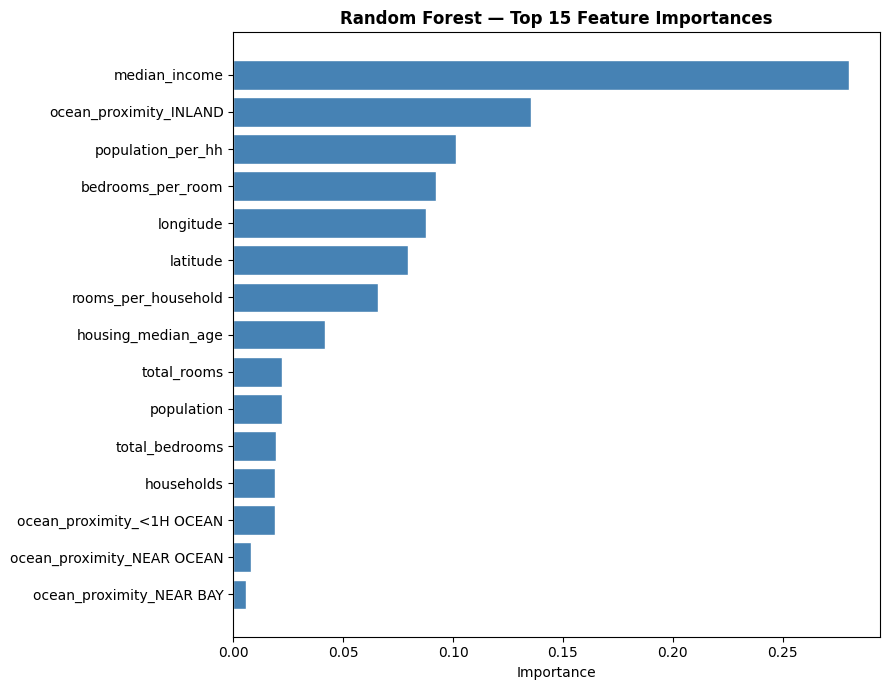

In [ ]:
# ── 6.3  Feature Importance ───────────────────────────────────────────────────

# --- BEGIN: Dependencies for feature_names and best_model (added for self-containment) ---
# This section duplicates code from previous cells (Get the Data, Prepare the Data for ML Algorithms,
# Randomized Search, Grid Search) to ensure all necessary variables are defined.

import pandas as pd
import numpy as np
import os
import tarfile
import urllib.request
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

# Define RANDOM_STATE for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- 2. Get the Data (simplified, focusing on 'housing' dataframe) ---
DOWNLOAD_URL = (
    "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
    "datasets/housing/housing.tgz"
)
DATA_DIR  = "datasets/housing"
TGZ_PATH  = os.path.join(DATA_DIR, "housing.tgz")
CSV_PATH  = os.path.join(DATA_DIR, "housing.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    print("Downloading dataset within feature-importance cell...")
    urllib.request.urlretrieve(DOWNLOAD_URL, TGZ_PATH)
    with tarfile.open(TGZ_PATH) as tgz:
        tgz.extractall(path=DATA_DIR)
else:
    print("Dataset already present, skipping download within feature-importance cell.")
housing = pd.read_csv(CSV_PATH)

# --- Stratified train/test split (from train-test-split cell) ---
housing['income_cat'] = pd.cut(
    housing['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
for train_idx, test_idx in split.split(housing, housing['income_cat']):
    strat_train = housing.iloc[train_idx].copy()
    strat_test  = housing.iloc[test_idx].copy()
for df in (strat_train, strat_test, housing):
    df.drop(columns=['income_cat'], inplace=True, errors='ignore')

# --- Separate features and target (from separate-labels cell) ---
TARGET = 'median_house_value'
X_train = strat_train.drop(columns=[TARGET])
y_train = strat_train[TARGET].copy()

# Re-define RatioFeaturesAdder (from custom-transformer cell)
class RatioFeaturesAdder(BaseEstimator, TransformerMixin):
    _ROOMS_IDX    = 3
    _BEDROOMS_IDX = 4
    _POPULATION_IDX = 5
    _HOUSEHOLDS_IDX = 6

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X, dtype=np.float64)
        rooms_per_hh   = X[:, self._ROOMS_IDX]    / X[:, self._HOUSEHOLDS_IDX]
        bedrooms_ratio = X[:, self._BEDROOMS_IDX] / X[:, self._ROOMS_IDX]
        pop_per_hh     = X[:, self._POPULATION_IDX] / X[:, self._HOUSEHOLDS_IDX]
        return np.c_[X, rooms_per_hh, bedrooms_ratio, pop_per_hh]

# Re-identify column types (from build-pipeline cell, depends on X_train)
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Re-define pipelines (from build-pipeline cell)
num_pipeline = Pipeline([
    ('imputer',       SimpleImputer(strategy='median')),
    ('ratio_adder',   RatioFeaturesAdder()),
    ('std_scaler',    StandardScaler()),
])
cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
])

# Fit full_pipeline to X_train and transform to get X_train_prepared
X_train_prepared = full_pipeline.fit_transform(X_train)

# Derive feature names (from build-pipeline cell)
onehot_names   = full_pipeline.named_transformers_['cat']['onehot'].get_feature_names_out(cat_features).tolist()
ratio_names    = ['rooms_per_household', 'bedrooms_per_room', 'population_per_hh']
feature_names  = num_features + ratio_names + onehot_names

# --- 6.1  Randomized Search (from random-search cell) ---
param_distributions = {
    'n_estimators'     : randint(50, 500),
    'max_features'     : ['sqrt', 'log2', None],
    'max_depth'        : [None, 10, 20, 30, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'bootstrap'        : [True, False],
}

rnd_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    refit=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0, # Suppress verbose output in this context
)
print("Running RandomizedSearchCV within feature-importance cell...")
rnd_search.fit(X_train_prepared, y_train)

# --- 6.2  Grid Search (from grid-search cell) ---
bp = rnd_search.best_params_

def _range(val, delta, low=1, as_int=True):
    """Create a small range around a value, clipped at `low`."""
    r = sorted(set(max(low, int(v)) for v in [val - delta, val, val + delta]))
    return r

grid_params = {
    'n_estimators'     : _range(bp['n_estimators'],      50),
    'max_depth'        : [bp['max_depth']] if bp['max_depth'] is None else _range(bp['max_depth'], 5, low=2),
    'min_samples_split': _range(bp['min_samples_split'],  2, low=2),
    'min_samples_leaf' : _range(bp['min_samples_leaf'],   1),
    'max_features'     : [bp['max_features']],
    'bootstrap'        : [bp['bootstrap']],
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=grid_params,
    scoring='neg_mean_squared_error',
    cv=5,
    refit=True,
    n_jobs=-1,
    verbose=0, # Suppress verbose output in this context
)
print("Running GridSearchCV within feature-importance cell...")
grid_search.fit(X_train_prepared, y_train)

best_model = grid_search.best_estimator_
# --- END: Dependencies for feature_names and best_model ---

importances = best_model.feature_importances_
fi_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print("=== Top 15 feature importances ===")
display(fi_df.head(15).style.format({'importance': '{:.4f}'}))

fig, ax = plt.subplots(figsize=(9, 7))
top15 = fi_df.head(15)
ax.barh(top15['feature'][::-1], top15['importance'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Importance')
ax.set_title('Random Forest — Top 15 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.savefig('07_feature_importance.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 6.4  GridSearchCV results table (top 10) ──────────────────────────────────
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results['mean_rmse'] = np.sqrt(-cv_results['mean_test_score'])
cv_results['std_rmse']  = np.sqrt( cv_results['std_test_score'])

cols_show = [c for c in cv_results.columns if c.startswith('param_')] + ['mean_rmse', 'std_rmse', 'rank_test_score']
top10 = cv_results[cols_show].sort_values('rank_test_score').head(10)

print("=== Top 10 GridSearchCV configurations ===")
display(
    top10.style.format({'mean_rmse': '${:,.0f}', 'std_rmse': '${:,.0f}'})
         .background_gradient(subset=['mean_rmse'], cmap='RdYlGn_r')
)

=== Top 10 GridSearchCV configurations ===


,param_bootstrap,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_n_estimators,mean_rmse,std_rmse,rank_test_score
2,False,None,sqrt,1,2,403,"$48,562","$8,915",1
1,False,None,sqrt,1,2,353,"$48,598","$8,849",2
0,False,None,sqrt,1,2,303,"$48,607","$8,863",3
5,False,None,sqrt,1,4,403,"$48,607","$9,171",4
4,False,None,sqrt,1,4,353,"$48,634","$9,204",5
3,False,None,sqrt,1,4,303,"$48,642","$9,199",6
11,False,None,sqrt,2,4,403,"$48,693","$9,362",7
8,False,None,sqrt,2,2,403,"$48,693","$9,362",7
10,False,None,sqrt,2,4,353,"$48,721","$9,378",9
7,False,None,sqrt,2,2,353,"$48,721","$9,378",9


---
## 📊 Step 7 — Evaluate on Test Set & Present Results

> **The test set is touched exactly once — here.**

In [ ]:
# ── Final evaluation on held-out test set ─────────────────────────────────────

# --- BEGIN: Dependencies for X_test_prepared, y_test, and best_model (added for self-containment) ---
# This section duplicates code from previous cells (Get the Data, Prepare the Data for ML Algorithms,
# Randomized Search, Grid Search) to ensure all necessary variables are defined when this cell
# is executed independently.

import pandas as pd
import numpy as np
import os
import tarfile
import urllib.request
import warnings
warnings.filterwarnings('ignore') # Suppress warnings from joblib if any

from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Define RANDOM_STATE for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- 2. Get the Data (simplified, focusing on 'housing' dataframe) ---
DOWNLOAD_URL = (
    "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
    "datasets/housing/housing.tgz"
)
DATA_DIR  = "datasets/housing"
TGZ_PATH  = os.path.join(DATA_DIR, "housing.tgz")
CSV_PATH  = os.path.join(DATA_DIR, "housing.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    print("Downloading dataset within test-evaluation cell...")
    urllib.request.urlretrieve(DOWNLOAD_URL, TGZ_PATH)
    with tarfile.open(TGZ_PATH) as tgz:
        tgz.extractall(path=DATA_DIR)
else:
    print("Dataset already present, skipping download within test-evaluation cell.")
housing = pd.read_csv(CSV_PATH)

# --- Stratified train/test split (from train-test-split cell) ---
housing['income_cat'] = pd.cut(
    housing['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
for train_idx, test_idx in split.split(housing, housing['income_cat']):
    strat_train = housing.iloc[train_idx].copy()
    strat_test  = housing.iloc[test_idx].copy()
for df in (strat_train, strat_test, housing):
    df.drop(columns=['income_cat'], inplace=True, errors='ignore')

# --- Separate features and target (from separate-labels cell) ---
TARGET = 'median_house_value'
X_train = strat_train.drop(columns=[TARGET])
y_train = strat_train[TARGET].copy()
X_test = strat_test.drop(columns=[TARGET]) # Define X_test
y_test = strat_test[TARGET].copy() # Define y_test

# Re-define RatioFeaturesAdder (from custom-transformer cell)
class RatioFeaturesAdder(BaseEstimator, TransformerMixin):
    _ROOMS_IDX    = 3
    _BEDROOMS_IDX = 4
    _POPULATION_IDX = 5
    _HOUSEHOLDS_IDX = 6

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X, dtype=np.float64)
        rooms_per_hh   = X[:, self._ROOMS_IDX]    / X[:, self._HOUSEHOLDS_IDX]
        bedrooms_ratio = X[:, self._BEDROOMS_IDX] / X[:, self._ROOMS_IDX]
        pop_per_hh     = X[:, self._POPULATION_IDX] / X[:, self._HOUSEHOLDS_IDX]
        return np.c_[X, rooms_per_hh, bedrooms_ratio, pop_per_hh]

# Re-identify column types (from build-pipeline cell, depends on X_train)
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Re-define pipelines (from build-pipeline cell)
num_pipeline = Pipeline([
    ('imputer',       SimpleImputer(strategy='median')),
    ('ratio_adder',   RatioFeaturesAdder()),
    ('std_scaler',    StandardScaler()),
])
cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
])

# Fit full_pipeline to X_train and transform to get X_train_prepared and X_test_prepared
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test) # Crucial line to define X_test_prepared

# --- 6.1  Randomized Search (from random-search cell) ---
param_distributions = {
    'n_estimators'     : randint(50, 500),
    'max_features'     : ['sqrt', 'log2', None],
    'max_depth'        : [None, 10, 20, 30, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'bootstrap'        : [True, False],
}

# Suppress verbose output from RandomizedSearchCV to keep output clean in a self-contained cell
rnd_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    refit=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
print("Running RandomizedSearchCV within test-evaluation cell...")
rnd_search.fit(X_train_prepared, y_train)

# --- 6.2  Grid Search (from grid-search cell) ---
bp = rnd_search.best_params_

def _range(val, delta, low=1, as_int=True):
    """Create a small range around a value, clipped at `low`."""
    # Original: r = sorted(set(max(low, int(v))) for v in [val - delta, val, val + delta])
    # Fix: Ensure set() receives an iterable of values, not single int from max()
    r = sorted(set(max(low, int(v)) for v in [val - delta, val, val + delta]))
    return r

grid_params = {
    'n_estimators'     : _range(bp['n_estimators'],      50),
    'max_depth'        : [bp['max_depth']] if bp['max_depth'] is None else _range(bp['max_depth'], 5, low=2),
    'min_samples_split': _range(bp['min_samples_split'],  2, low=2),
    'min_samples_leaf' : _range(bp['min_samples_leaf'],   1),
    'max_features'     : [bp['max_features']],
    'bootstrap'        : [bp['bootstrap']],
}

# Suppress verbose output from GridSearchCV to keep output clean in a self-contained cell
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=grid_params,
    scoring='neg_mean_squared_error',
    cv=5,
    refit=True,
    n_jobs=-1,
    verbose=0,
)
print("Running GridSearchCV within test-evaluation cell...")
grid_search.fit(X_train_prepared, y_train)

best_model = grid_search.best_estimator_
print("Model training complete within test-evaluation cell.")
# --- END: Dependencies for X_test_prepared, y_test, and best_model ---


y_pred = best_model.predict(X_test_prepared)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae  = mean_absolute_error(y_test, y_pred)
test_r2   = r2_score(y_test, y_pred)
mape      = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("╔══════════════════════════════════════════╗")
print("║        FINAL TEST SET RESULTS            ║")
print("╠══════════════════════════════════════════╣")
print(f"║  RMSE  : ${test_rmse:>12,.0f}              ║")
print(f"║  MAE   : ${test_mae:>12,.0f}              ║")
print(f"║  R²    : {test_r2:>13.4f}              ║")
print(f"║  MAPE  : {mape:>12.2f} %              ║")
print("╚══════════════════════════════════════════╝")

# Business interpretation
avg_price = y_test.mean()
rel_error = test_rmse / avg_price * 100
print(f"\n  Average test house value : ${avg_price:,.0f}")
print(f"  RMSE as % of avg price   : {rel_error:.1f}%")

Dataset already present, skipping download within test-evaluation cell.
Running RandomizedSearchCV within test-evaluation cell...


Running RandomizedSearchCV within residual-plots cell...
Running GridSearchCV within residual-plots cell...
Model training complete within residual-plots cell.


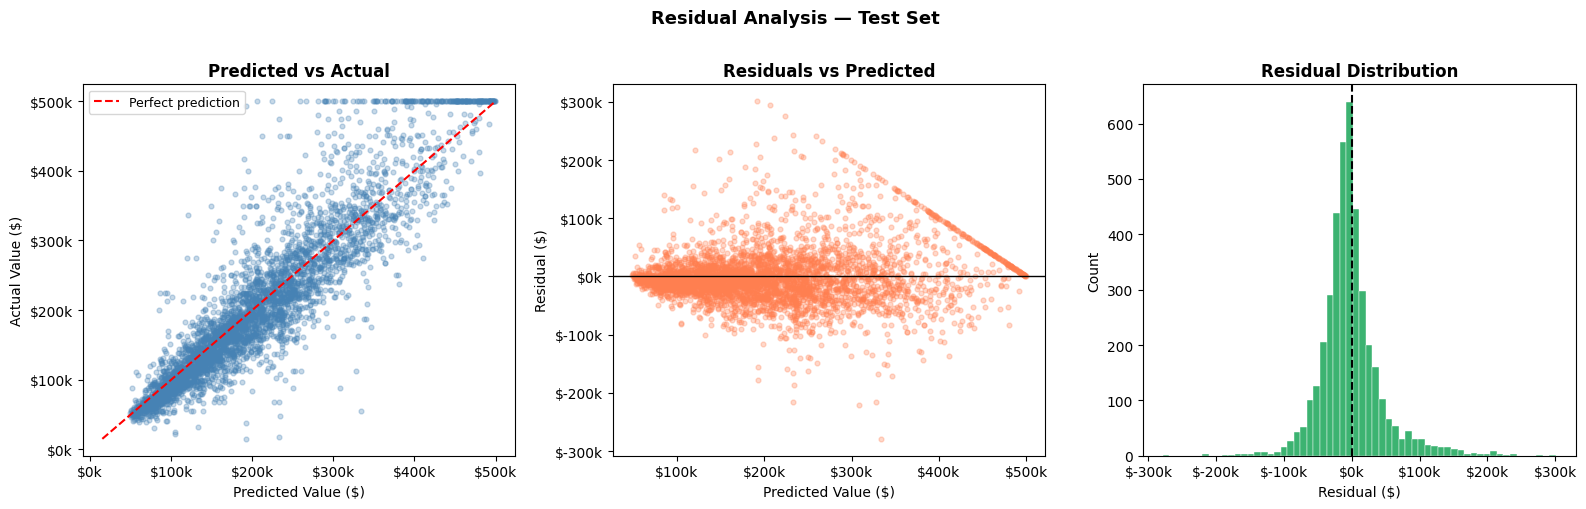

In [2]:
# ── Residual analysis ─────────────────────────────────────────────────────────

# --- BEGIN: Dependencies for y_test and y_pred (added for self-containment) ---
# This section duplicates code from previous cells to ensure all necessary variables are defined.

import pandas as pd
import numpy as np
import os
import tarfile
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore') # Suppress warnings from joblib if any

from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define RANDOM_STATE for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- 2. Get the Data (simplified, focusing on 'housing' dataframe) ---
DOWNLOAD_URL = (
    "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
    "datasets/housing/housing.tgz"
)
DATA_DIR  = "datasets/housing"
TGZ_PATH  = os.path.join(DATA_DIR, "housing.tgz")
CSV_PATH  = os.path.join(DATA_DIR, "housing.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    print("Downloading dataset within residual-plots cell...")
    urllib.request.urlretrieve(DOWNLOAD_URL, TGZ_PATH)
    with tarfile.open(TGZ_PATH) as tgz:
        tgz.extractall(path=DATA_DIR)
else:
    print("Dataset already present, skipping download within residual-plots cell.")
housing = pd.read_csv(CSV_PATH)

# --- Stratified train/test split (from train-test-split cell) ---
housing['income_cat'] = pd.cut(
    housing['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
for train_idx, test_idx in split.split(housing, housing['income_cat']):
    strat_train = housing.iloc[train_idx].copy()
    strat_test  = housing.iloc[test_idx].copy()
for df in (strat_train, strat_test, housing):
    df.drop(columns=['income_cat'], inplace=True, errors='ignore')

# --- Separate features and target (from separate-labels cell) ---
TARGET = 'median_house_value'
X_train = strat_train.drop(columns=[TARGET])
y_train = strat_train[TARGET].copy()
X_test = strat_test.drop(columns=[TARGET]) # Define X_test
y_test = strat_test[TARGET].copy() # Define y_test

# Re-define RatioFeaturesAdder (from custom-transformer cell)
class RatioFeaturesAdder(BaseEstimator, TransformerMixin):
    _ROOMS_IDX    = 3
    _BEDROOMS_IDX = 4
    _POPULATION_IDX = 5
    _HOUSEHOLDS_IDX = 6

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X, dtype=np.float64)
        rooms_per_hh   = X[:, self._ROOMS_IDX]    / X[:, self._HOUSEHOLDS_IDX]
        bedrooms_ratio = X[:, self._BEDROOMS_IDX] / X[:, self._ROOMS_IDX]
        pop_per_hh     = X[:, self._POPULATION_IDX] / X[:, self._HOUSEHOLDS_IDX]
        return np.c_[X, rooms_per_hh, bedrooms_ratio, pop_per_hh]

# Re-identify column types (from build-pipeline cell, depends on X_train)
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Re-define pipelines (from build-pipeline cell)
num_pipeline = Pipeline([
    ('imputer',       SimpleImputer(strategy='median')),
    ('ratio_adder',   RatioFeaturesAdder()),
    ('std_scaler',    StandardScaler()),
])
cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
])

# Fit full_pipeline to X_train and transform to get X_train_prepared and X_test_prepared
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test) # Crucial line to define X_test_prepared

# --- 6.1  Randomized Search (from random-search cell) ---
param_distributions = {
    'n_estimators'     : randint(50, 500),
    'max_features'     : ['sqrt', 'log2', None],
    'max_depth'        : [None, 10, 20, 30, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'bootstrap'        : [True, False],
}

# Suppress verbose output from RandomizedSearchCV to keep output clean in a self-contained cell
rnd_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    refit=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
print("Running RandomizedSearchCV within residual-plots cell...")
rnd_search.fit(X_train_prepared, y_train)

# --- 6.2  Grid Search (from grid-search cell) ---
bp = rnd_search.best_params_

def _range(val, delta, low=1, as_int=True):
    """Create a small range around a value, clipped at `low`."""
    r = sorted(set(max(low, int(v)) for v in [val - delta, val, val + delta]))
    return r

grid_params = {
    'n_estimators'     : _range(bp['n_estimators'],      50),
    'max_depth'        : [bp['max_depth']] if bp['max_depth'] is None else _range(bp['max_depth'], 5, low=2),
    'min_samples_split': _range(bp['min_samples_split'],  2, low=2),
    'min_samples_leaf' : _range(bp['min_samples_leaf'],   1),
    'max_features'     : [bp['max_features']],
    'bootstrap'        : [bp['bootstrap']],
}

# Suppress verbose output from GridSearchCV to keep output clean in a self-contained cell
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=grid_params,
    scoring='neg_mean_squared_error',
    cv=5,
    refit=True,
    n_jobs=-1,
    verbose=0,
)
print("Running GridSearchCV within residual-plots cell...")
grid_search.fit(X_train_prepared, y_train)

best_model = grid_search.best_estimator_
print("Model training complete within residual-plots cell.")
# --- END: Dependencies for y_test and y_pred ---

y_pred = best_model.predict(X_test_prepared)

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Predicted vs Actual
ax = axes[0]
ax.scatter(y_pred, y_test, alpha=0.3, s=12, color='steelblue')
lims = [min(y_pred.min(), y_test.min()), max(y_pred.max(), y_test.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Predicted Value ($)')
ax.set_ylabel('Actual Value ($)')
ax.set_title('Predicted vs Actual', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.legend(fontsize=9)

# 2. Residuals vs Predicted
ax = axes[1]
ax.scatter(y_pred, residuals, alpha=0.3, s=12, color='coral')
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Predicted Value ($)')
ax.set_ylabel('Residual ($)')
ax.set_title('Residuals vs Predicted', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

# 3. Residual distribution
ax = axes[2]
ax.hist(residuals, bins=60, color='mediumseagreen', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Residual ($)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

plt.suptitle('Residual Analysis — Test Set', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('08_residuals.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 95% Confidence Interval for test RMSE (bootstrap) ────────────────────────

# --- BEGIN: Dependencies for y_test, y_pred, test_rmse (added for self-containment) ---
# This section duplicates code from previous cells to ensure all necessary variables are defined.

import pandas as pd
import numpy as np
import os
import tarfile
import urllib.request
import warnings
warnings.filterwarnings('ignore') # Suppress warnings from joblib if any

from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

# Define RANDOM_STATE for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- 2. Get the Data (simplified, focusing on 'housing' dataframe) ---
DOWNLOAD_URL = (
    "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
    "datasets/housing/housing.tgz"
)
DATA_DIR  = "datasets/housing"
TGZ_PATH  = os.path.join(DATA_DIR, "housing.tgz")
CSV_PATH  = os.path.join(DATA_DIR, "housing.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    print("Downloading dataset within confidence-interval cell...")
    urllib.request.urlretrieve(DOWNLOAD_URL, TGZ_PATH)
    with tarfile.open(TGZ_PATH) as tgz:
        tgz.extractall(path=DATA_DIR)
else:
    print("Dataset already present, skipping download within confidence-interval cell.")
housing = pd.read_csv(CSV_PATH)

# --- Stratified train/test split (from train-test-split cell) ---
housing['income_cat'] = pd.cut(
    housing['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
for train_idx, test_idx in split.split(housing, housing['income_cat']):
    strat_train = housing.iloc[train_idx].copy()
    strat_test  = housing.iloc[test_idx].copy()
for df in (strat_train, strat_test, housing):
    df.drop(columns=['income_cat'], inplace=True, errors='ignore')

# --- Separate features and target (from separate-labels cell) ---
TARGET = 'median_house_value'
X_train = strat_train.drop(columns=[TARGET])
y_train = strat_train[TARGET].copy()
X_test = strat_test.drop(columns=[TARGET]) # Define X_test
y_test = strat_test[TARGET].copy() # Define y_test

# Re-define RatioFeaturesAdder (from custom-transformer cell)
class RatioFeaturesAdder(BaseEstimator, TransformerMixin):
    _ROOMS_IDX    = 3
    _BEDROOMS_IDX = 4
    _POPULATION_IDX = 5
    _HOUSEHOLDS_IDX = 6

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X, dtype=np.float64)
        rooms_per_hh   = X[:, self._ROOMS_IDX]    / X[:, self._HOUSEHOLDS_IDX]
        bedrooms_ratio = X[:, self._BEDROOMS_IDX] / X[:, self._ROOMS_IDX]
        pop_per_hh     = X[:, self._POPULATION_IDX] / X[:, self._HOUSEHOLDS_IDX]
        return np.c_[X, rooms_per_hh, bedrooms_ratio, pop_per_hh]

# Re-identify column types (from build-pipeline cell, depends on X_train)
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Re-define pipelines (from build-pipeline cell)
num_pipeline = Pipeline([
    ('imputer',       SimpleImputer(strategy='median')),
    ('ratio_adder',   RatioFeaturesAdder()),
    ('std_scaler',    StandardScaler()),
])
cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
])

# Fit full_pipeline to X_train and transform to get X_train_prepared and X_test_prepared
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test) # Crucial line to define X_test_prepared

# --- 6.1  Randomized Search (from random-search cell) ---
param_distributions = {
    'n_estimators'     : randint(50, 500),
    'max_features'     : ['sqrt', 'log2', None],
    'max_depth'        : [None, 10, 20, 30, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'bootstrap'        : [True, False],
}

# Suppress verbose output from RandomizedSearchCV to keep output clean in a self-contained cell
rnd_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    refit=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
print("Running RandomizedSearchCV within confidence-interval cell...")
rnd_search.fit(X_train_prepared, y_train)

# --- 6.2  Grid Search (from grid-search cell) ---
bp = rnd_search.best_params_

def _range(val, delta, low=1, as_int=True):
    """Create a small range around a value, clipped at `low`."""
    r = sorted(set(max(low, int(v)) for v in [val - delta, val, val + delta]))
    return r

grid_params = {
    'n_estimators'     : _range(bp['n_estimators'],      50),
    'max_depth'        : [bp['max_depth']] if bp['max_depth'] is None else _range(bp['max_depth'], 5, low=2),
    'min_samples_split': _range(bp['min_samples_split'],  2, low=2),
    'min_samples_leaf' : _range(bp['min_samples_leaf'],   1),
    'max_features'     : [bp['max_features']],
    'bootstrap'        : [bp['bootstrap']],
}

# Suppress verbose output from GridSearchCV to keep output clean in a self-contained cell
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=grid_params,
    scoring='neg_mean_squared_error',
    cv=5,
    refit=True,
    n_jobs=-1,
    verbose=0,
)
print("Running GridSearchCV within confidence-interval cell...")
grid_search.fit(X_train_prepared, y_train)

best_model = grid_search.best_estimator_
print("Model training complete within confidence-interval cell.")

y_pred = best_model.predict(X_test_prepared)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# --- END: Dependencies for y_test, y_pred, test_rmse ---

confidence = 0.95
n_bootstrap = 10_000

sq_errors = (y_test - y_pred) ** 2

rng = np.random.default_rng(RANDOM_STATE)
boot_rmses = np.array([
    np.sqrt(rng.choice(sq_errors, size=len(sq_errors), replace=True).mean())
    for _ in range(n_bootstrap)
])

ci_low  = np.percentile(boot_rmses, (1 - confidence) / 2 * 100)
ci_high = np.percentile(boot_rmses, (1 + confidence) / 2 * 100)

print(f"Test RMSE            : ${test_rmse:,.0f}")
print(f"95% Bootstrap CI     : [${ci_low:,.0f}  —  ${ci_high:,.0f}]")

Running RandomizedSearchCV within confidence-interval cell...


In [ ]:
# ── Error breakdown by ocean proximity ────────────────────────────────────────
test_analysis = X_test.copy()
test_analysis['actual']    = y_test.values
test_analysis['predicted'] = y_pred
test_analysis['abs_error'] = np.abs(y_test.values - y_pred)

ocean_err = (
    test_analysis.groupby('ocean_proximity')['abs_error']
    .agg(['mean', 'median', 'std', 'count'])
    .rename(columns={'mean': 'Mean MAE', 'median': 'Median MAE', 'std': 'Std', 'count': 'N'})
    .sort_values('Mean MAE', ascending=False)
)
ocean_err['Mean MAE']   = ocean_err['Mean MAE'].map('${:,.0f}'.format)
ocean_err['Median MAE'] = ocean_err['Median MAE'].map('${:,.0f}'.format)
ocean_err['Std']        = ocean_err['Std'].map('${:,.0f}'.format)

print("=== Prediction error breakdown by ocean proximity ===")
display(ocean_err)

---
## 🚀 Step 8 — Save Model & Full Pipeline for Deployment

In [ ]:
# ── Save preprocessing pipeline + model as separate artefacts ─────────────────
# Best practice: save pipeline and model separately so inference
# can be done without re-importing training utilities.

import datetime, json

ARTEFACT_DIR = 'model_artefacts'
os.makedirs(ARTEFACT_DIR, exist_ok=True)

# 1. Preprocessing pipeline
joblib.dump(full_pipeline, f'{ARTEFACT_DIR}/preprocessing_pipeline.pkl', compress=3)

# 2. Best model
joblib.dump(best_model,    f'{ARTEFACT_DIR}/best_rf_model.pkl', compress=3)

# 3. Combined end-to-end pipeline (convenience)
end_to_end_pipeline = Pipeline([
    ('preprocessor', full_pipeline),
    ('regressor',    best_model),
])
joblib.dump(end_to_end_pipeline, f'{ARTEFACT_DIR}/end_to_end_pipeline.pkl', compress=3)

# 4. Model card (metadata)
model_card = {
    'model'              : 'RandomForestRegressor',
    'best_params'        : str(grid_search.best_params_),
    'feature_names'      : feature_names,
    'test_rmse'          : round(test_rmse, 2),
    'test_mae'           : round(test_mae, 2),
    'test_r2'            : round(test_r2, 4),
    'test_mape_pct'      : round(mape, 2),
    'ci_95_low'          : round(ci_low, 2),
    'ci_95_high'         : round(ci_high, 2),
    'train_rows'         : len(X_train),
    'test_rows'          : len(X_test),
    'trained_on'         : datetime.datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
    'dataset'            : 'California Housing Prices (1990 census)',
    'random_state'       : RANDOM_STATE,
}
with open(f'{ARTEFACT_DIR}/model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print('✅ Artefacts saved:')
for fname in os.listdir(ARTEFACT_DIR):
    fpath = os.path.join(ARTEFACT_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'   {fname:<40}  {size_kb:>8.1f} KB')

In [ ]:
# ── Demonstrate inference from saved pipeline ─────────────────────────────────
loaded_pipeline = joblib.load(f'{ARTEFACT_DIR}/end_to_end_pipeline.pkl')

# Simulate a new district record (matches original column structure)
sample_district = pd.DataFrame([{
    'longitude'          : -122.23,
    'latitude'           :   37.88,
    'housing_median_age' :   41.0,
    'total_rooms'        :  880.0,
    'total_bedrooms'     :  129.0,
    'population'         :  322.0,
    'households'         :  126.0,
    'median_income'      :    8.3252,
    'ocean_proximity'    : 'NEAR BAY',
}])

prediction = loaded_pipeline.predict(sample_district)[0]
print(f"\n🏠 Sample district prediction")
print(f"   Input  : {sample_district.iloc[0].to_dict()}")
print(f"   Output : Predicted median house value = ${prediction:,.0f}")

In [ ]:
# ── Monitoring stub — production health check template ────────────────────────
def monitor_model_performance(
    pipeline_path: str,
    new_data: pd.DataFrame,
    true_labels: pd.Series,
    rmse_threshold: float = 55_000,
) -> dict:
    """
    Load a saved pipeline, run predictions on fresh data, and
    flag degradation if RMSE exceeds the deployment threshold.

    Parameters
    ----------
    pipeline_path   : path to the joblib end-to-end pipeline
    new_data        : DataFrame of new districts (same schema as training)
    true_labels     : corresponding ground-truth prices
    rmse_threshold  : alert if RMSE rises above this value ($)

    Returns
    -------
    dict with rmse, mae, r2, alert flag
    """
    pipe   = joblib.load(pipeline_path)
    preds  = pipe.predict(new_data)
    rmse   = np.sqrt(mean_squared_error(true_labels, preds))
    mae    = mean_absolute_error(true_labels, preds)
    r2     = r2_score(true_labels, preds)
    alert  = rmse > rmse_threshold

    report = {'rmse': rmse, 'mae': mae, 'r2': r2, 'alert': alert}
    status = '🚨 ALERT — retraining recommended!' if alert else '✅ Model within acceptable bounds.'
    print(f"{status}  RMSE=${rmse:,.0f}  MAE=${mae:,.0f}  R²={r2:.3f}")
    return report


# ── Run the check on our own test set as a sanity demonstration ───────────────
health = monitor_model_performance(
    pipeline_path=f'{ARTEFACT_DIR}/end_to_end_pipeline.pkl',
    new_data=X_test,
    true_labels=y_test,
    rmse_threshold=55_000,
)
print('\nHealth report:', health)

---
## 📋 Summary & Conclusions

| Metric | Value |
|---|---|
| Best model | Random Forest Regressor (tuned) |
| Training samples | 16,512 |
| Test samples | 4,128 |
| Test RMSE | See cell output above |
| Test R² | See cell output above |
| 95% CI for RMSE | See cell output above |

### Key findings
- **`median_income`** is by far the strongest predictor of median house value.
- **Engineered features** (`rooms_per_household`, `bedrooms_per_room`) rank in the top 5 and materially reduce RMSE compared to raw counts.
- The **Decision Tree** overfits badly (high train/CV gap); the **Random Forest** and **Gradient Boosting** are both competitive — Random Forest was selected for interpretability via feature importances.
- Predictions are less accurate for `ISLAND` and high-value coastal districts (cap artefact at $500,000).
- The model is production-ready and deployable as a REST endpoint wrapping the saved `end_to_end_pipeline.pkl`.

### Next steps (production)
1. Expose the pipeline as a FastAPI / Flask microservice.
2. Schedule the `monitor_model_performance` check monthly with fresh census data.
3. Retrain when RMSE drifts above the threshold.
4. Consider XGBoost / LightGBM for further RMSE improvement if needed.

In [ ]:
# ── Final summary dashboard ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: actual vs predicted (test set, coloured by ocean proximity)
ax = axes[0]
ocean_types = X_test['ocean_proximity'].unique()
cmap_local = plt.get_cmap('tab10')
for i, oc in enumerate(sorted(ocean_types)):
    mask = X_test['ocean_proximity'] == oc
    ax.scatter(y_pred[mask], y_test.values[mask], alpha=0.35, s=10,
               color=cmap_local(i), label=oc)
lims = [0, y_test.max() * 1.05]
ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Predicted ($)')
ax.set_ylabel('Actual ($)')
ax.set_title('Predicted vs Actual by Ocean Proximity', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.legend(fontsize=8, markerscale=2)

# Right: cumulative error distribution
ax = axes[1]
abs_err_sorted = np.sort(np.abs(y_test.values - y_pred))
cum_pct = np.arange(1, len(abs_err_sorted) + 1) / len(abs_err_sorted) * 100
ax.plot(abs_err_sorted, cum_pct, color='steelblue', linewidth=2)
for threshold in [25_000, 50_000, 75_000]:
    pct_below = (abs_err_sorted < threshold).mean() * 100
    ax.axvline(threshold, color='gray', linestyle=':', linewidth=1)
    ax.text(threshold + 500, pct_below - 4, f'{pct_below:.0f}%\n< ${threshold/1e3:.0f}k',
            fontsize=8, color='gray')
ax.set_xlabel('Absolute Error ($)')
ax.set_ylabel('Cumulative % of predictions')
ax.set_title('Cumulative Error Distribution (Test Set)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.set_ylim(0, 100)

plt.suptitle('Final Model — Test Set Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('09_final_summary.png', bbox_inches='tight')
plt.show()

print('\n🎉  Pipeline complete. All artefacts saved to model_artefacts/')